# Air Traffic Data Analysis - Student Exercise
## Inferential Statistics and Regression Analysis

**Student Template - Complete the TODO sections**

In this exercise, you will analyze air traffic data using inferential statistics and regression techniques. Follow the instructions and complete each section marked with `#TODO`.

### Dataset Description:
- **Dom_Pax**: Domestic Air Travel Passengers
- **Int_Pax**: International Air Travel Passengers  
- **Pax**: Total Air Travel Passengers
- **Dom_Flt**: Number of Flights (Domestic)
- **Int_Flt**: Number of Flights (International)
- **Flt**: Number of Flights (Total)
- **Dom_RPM**: Revenue Passenger-miles (Domestic)

## 1. Setup and Data Loading

In [3]:
# TODO: Import necessary libraries
# Hint: You'll need pandas, numpy, matplotlib, seaborn, scipy.stats, and sklearn modules

# Your code here:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler


# Set up plotting style (optional)
plt.style.use('default')
sns.set_palette("husl")

In [6]:


# TODO: Load the dataset
# Hint: Use pd.read_csv() to load 'air_traffic_data.csv'
# If the file doesn't exist, the code below will create sample data for you

try:
    # Your code to load the dataset:
    df = pd.read_csv('air_traffic_data.csv')
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Creating sample air traffic data...")

    # Create sample data
    np.random.seed(42)
    n_samples = 200

    # Generate correlated data
    dom_flights = np.random.normal(15000, 3000, n_samples)
    int_flights = np.random.normal(8000, 2000, n_samples)

    dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
    int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)

    dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)

    # Ensure positive values
    dom_flights = np.abs(dom_flights)
    int_flights = np.abs(int_flights)
    dom_pax = np.abs(dom_pax)
    int_pax = np.abs(int_pax)
    dom_rpm = np.abs(dom_rpm)

    df = pd.DataFrame({
        'Dom_Flt': dom_flights.astype(int),
        'Int_Flt': int_flights.astype(int),
        'Flt': (dom_flights + int_flights).astype(int),
        'Dom_Pax': dom_pax.astype(int),
        'Int_Pax': int_pax.astype(int),
        'Pax': (dom_pax + int_pax).astype(int),
        'Dom_RPM': dom_rpm.astype(int)
    })

    print("Sample data created successfully!")
    print(f"Shape: {df.shape}")

Creating sample air traffic data...
Sample data created successfully!
Shape: (200, 7)


## 2. Exploratory Data Analysis

In [7]:
# TODO: Display basic information about the dataset
# Hint: Use df.info(), df.head(), and df.describe() to explore the data

print("Dataset Info:")
# Your code here:
df.info()

print("\nFirst 5 rows:")
# Your code here:
df.head

print("\nBasic Statistics:")
# Your code here:
df.describe()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Dom_Flt  200 non-null    int64
 1   Int_Flt  200 non-null    int64
 2   Flt      200 non-null    int64
 3   Dom_Pax  200 non-null    int64
 4   Int_Pax  200 non-null    int64
 5   Pax      200 non-null    int64
 6   Dom_RPM  200 non-null    int64
dtypes: int64(7)
memory usage: 11.1 KB

First 5 rows:

Basic Statistics:


,Dom_Flt,Int_Flt,Flt,Dom_Pax,Int_Pax,Pax,Dom_RPM
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,2.000000e+02
mean,14877.170000,8171.215000,23048.875000,175331.340000,126924.080000,302255.885000,1.406821e+08
std,2793.014056,1973.997049,3570.262195,44857.540799,39219.620597,59904.148005,4.199422e+07
min,7140.000000,1517.000000,13177.000000,81758.000000,36755.000000,163559.000000,6.330140e+07
25%,12883.750000,6787.750000,20647.000000,142793.750000,100451.000000,265141.250000,1.111673e+08
50%,14987.000000,8157.000000,23250.500000,171194.000000,125890.000000,297932.000000,1.348214e+08
75%,16502.250000,9374.000000,25237.250000,199115.000000,154947.000000,339630.250000,1.634872e+08
max,23160.000000,15705.000000,32333.000000,337112.000000,244469.000000,526087.000000,3.312472e+08


In [9]:
# TODO: Check for missing values and handle them if necessary
# Hint: Use df.isnull().sum() to check for missing values
# If there are missing values, decide whether to drop them (dropna()) or fill them (fillna())

print("Missing values:")
# Your code here:
df.isnull().sum()

# Handle missing values if any (uncomment and complete if needed)
# if df.isnull().sum().sum() > 0:
#     print("\nHandling missing values...")
#     df = # TODO: Complete this line (use dropna() or fillna())
#     print(f"New shape after handling missing values: {df.shape}")

Missing values:


,0
Dom_Flt,0
Int_Flt,0
Flt,0
Dom_Pax,0
Int_Pax,0
Pax,0
Dom_RPM,0


Correlation Matrix:
          Dom_Flt   Int_Flt       Flt   Dom_Pax   Int_Pax       Pax   Dom_RPM
Dom_Flt  1.000000  0.095161  0.834910  0.664181  0.024392  0.513322  0.559946
Int_Flt  0.095161  1.000000  0.627340  0.040427  0.665554  0.466015  0.028555
Flt      0.834910  0.627340  1.000000  0.541947  0.387060  0.659231  0.453840
Dom_Pax  0.664181  0.040427  0.541947  1.000000  0.010837  0.755916  0.901617
Int_Pax  0.024392  0.665554  0.387060  0.010837  1.000000  0.662822 -0.004699
Pax      0.513322  0.466015  0.659231  0.755916  0.662822  1.000000  0.672074
Dom_RPM  0.559946  0.028555  0.453840  0.901617 -0.004699  0.672074  1.000000


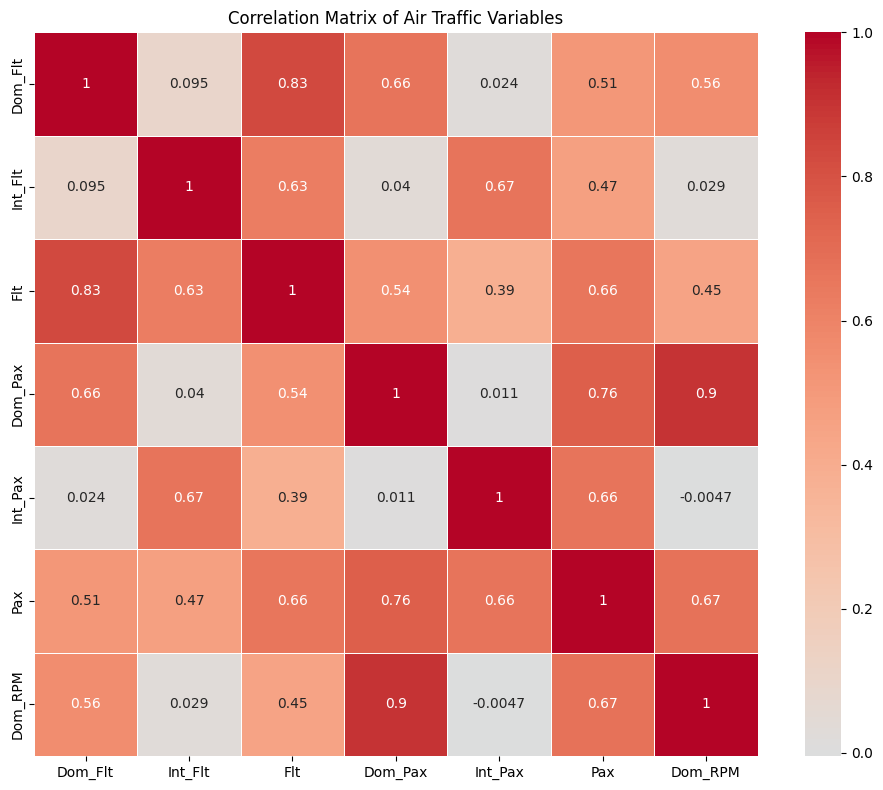

Strongest correlations:
  Dom_RPM vs Dom_Pax: 0.9016
  Flt vs Dom_Flt: 0.8349
  Pax vs Dom_Pax: 0.7559
  Dom_RPM vs Pax: 0.6721
  Int_Pax vs Int_Flt: 0.6656


In [13]:
# TODO: Create and analyze correlation matrix
# Hint: Use df.corr() to calculate correlations and sns.heatmap() to visualize

plt.figure(figsize=(10, 8))
# Calculate correlation matrix:
correlation_matrix = df.corr()
print("Correlation Matrix:")
print(correlation_matrix)

# Create heatmap:
# TODO: Use s with parameters:

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix of Air Traffic Variables')
plt.tight_layout()
plt.show()

# TODO: Find and print the strongest correlations
# Hint: Look at the correlation matrix values (excluding diagonal)
print("Strongest correlations:")

# Your analysis here:
# Create a mask to remove self-correlations and duplicate pairs
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
correlation_pairs = correlation_matrix.mask(mask).stack()

# Sort the correlations by absolute value
strongest_correlations = correlation_pairs.abs().sort_values(ascending=False)

# Print the top 5 strongest correlations
for (var1, var2), corr_value in strongest_correlations.head(5).items():
    original_corr = correlation_matrix.loc[var1, var2]
    print(f"  {var1} vs {var2}: {original_corr:.4f}")

## 3. Hypothesis Testing

In [16]:
# TODO: Hypothesis Test 1 - Compare domestic and international passengers
# Hint: Use stats.ttest_ind() to perform independent t-test


print("Hypothesis Test 1: Domestic vs International Passengers")
print("H0: Mean domestic passengers = Mean international passengers")
print("H1: Mean domestic passengers ≠ Mean international passengers")
print("Significance level: α = 0.05")

# Perform the t-test:
t_stat, p_value = stats.ttest_ind(df['Dom_Pax'], df['Int_Pax'])

print(f"\nResults:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

# TODO: Print the mean values for both groups
print(f"Mean Domestic Passengers: {df['Dom_Pax'].mean():.0f}")
print(f"Mean International Passengers: {df['Int_Pax'].mean():.0f}")

# TODO: Interpret the results
# Hint: Compare p_value with alpha (0.05) to make a decision
alpha = 0.05
if p_value < alpha:
    # TODO: Complete the conclusion for rejecting H0
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print("Interpretation: There is a statistically significant difference between the mean number of domestic and international passengers. Domestic passengers are significantly higher on average.")
else:
    # TODO: Complete the conclusion for failing to reject H0
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("Interpretation: There is no statistically significant difference between the mean number of domestic and international passengers.")

Hypothesis Test 1: Domestic vs International Passengers
H0: Mean domestic passengers = Mean international passengers
H1: Mean domestic passengers ≠ Mean international passengers
Significance level: α = 0.05

Results:
T-statistic: 11.4892
P-value: 0.000000
Mean Domestic Passengers: 175331
Mean International Passengers: 126924

Conclusion: Reject H0 (p < 0.05)
Interpretation: There is a statistically significant difference between the mean number of domestic and international passengers. Domestic passengers are significantly higher on average.


In [17]:
# TODO: Hypothesis Test 2 - Test correlation between total passengers and total flights
# Hint: Use stats.pearsonr() to test correlation significance

print("\nHypothesis Test 2: Correlation between Total Passengers and Total Flights")
print("H0: There is no correlation between total passengers and total flights (ρ = 0)")
print("H1: There is a correlation between total passengers and total flights (ρ ≠ 0)")
print("Significance level: α = 0.05")

# Perform correlation test:
correlation_coef, p_value_corr = stats.pearsonr(df['Pax'], df['Flt'])

print(f"\nResults:")
print(f"Correlation coefficient: {correlation_coef:.4f}")
print(f"P-value: {p_value_corr:.6f}")

# TODO: Interpret the correlation test results
# Hint: Compare p_value_corr with alpha and interpret the correlation coefficient
alpha = 0.05
if p_value_corr < alpha:
    print(f"\nConclusion: Reject H0 (p < {alpha})")
    print(f"There is a significant correlation between total passengers and total flights.")
    # TODO: Add interpretation about positive/negative correlation
    if correlation_coef > 0:
        print("Interpretation: There is a strong positive correlation, meaning as total flights increase, total passengers also tend to increase.")
    else:
        print("Interpretation: There is a strong negative correlation, meaning as total flights increase, total passengers tend to decrease.")
else:
    print(f"\nConclusion: Fail to reject H0 (p >= {alpha})")
    print("Interpretation: There is no statistically significant correlation between total passengers and total flights.")


Hypothesis Test 2: Correlation between Total Passengers and Total Flights
H0: There is no correlation between total passengers and total flights (ρ = 0)
H1: There is a correlation between total passengers and total flights (ρ ≠ 0)
Significance level: α = 0.05

Results:
Correlation coefficient: 0.6592
P-value: 0.000000

Conclusion: Reject H0 (p < 0.05)
There is a significant correlation between total passengers and total flights.
Interpretation: There is a strong positive correlation, meaning as total flights increase, total passengers also tend to increase.


## 4. Simple Linear Regression

In [20]:
# TODO: Build a simple linear regression model
# Goal: Predict Total Passengers from Total Flights
# Hint: Use sklearn's LinearRegression class

print("Simple Linear Regression: Predicting Total Passengers from Total Flights")

# Prepare the data:
X_simple = df[['Flt']]
y_simple = df['Pax']

# Split the data:
# TODO: Use train_test_split with test_size=0.2, random_state=42
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

# Create and train the model:
simple_model = LinearRegression()
# TODO: Fit the model using X_train_simple and y_train_simple
simple_model.fit(X_train_simple, y_train_simple)


# Make predictions:
y_pred_simple = simple_model.predict(X_test_simple)

# TODO: Calculate performance metrics
# Hint: Use r2_score, mean_squared_error, mean_absolute_error
r2_simple = r2_score(y_test_simple, y_pred_simple)
mse_simple = mean_squared_error(y_test_simple, y_pred_simple)
mae_simple = mean_absolute_error(y_test_simple, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)

print(f"\nModel Performance:")
print(f"R² Score: {r2_simple:.4f}")
print(f"Mean Squared Error: {mse_simple:.2f}")
print(f"Root Mean Squared Error: {rmse_simple:.2f}")
print(f"Mean Absolute Error: {mae_simple:.2f}")

# TODO: Print the model equation
# Hint: Use simple_model.intercept_ and simple_model.coef_[0]
print(f"\nModel Equation: Passengers = {simple_model.intercept_:.2f} + {simple_model.coef_[0]:.2f} × Flights")

Simple Linear Regression: Predicting Total Passengers from Total Flights

Model Performance:
R² Score: 0.2977
Mean Squared Error: 2141846835.14
Root Mean Squared Error: 46280.09
Mean Absolute Error: 36607.08

Model Equation: Passengers = 37484.48 + 11.45 × Flights


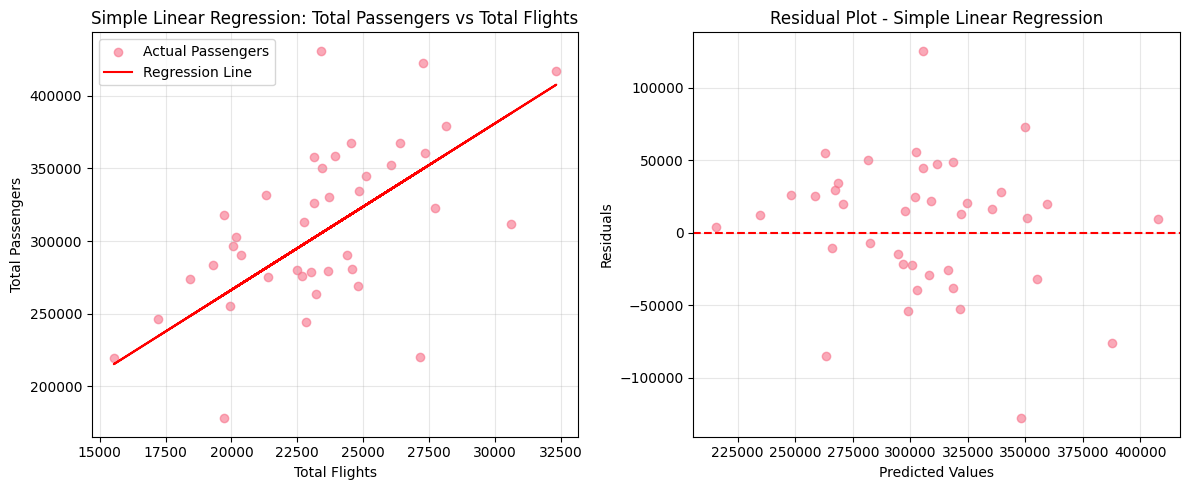

In [21]:
# TODO: Visualize the simple linear regression results
# Create two plots: scatter plot with regression line and residual plot

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# TODO: Create scatter plot of actual vs predicted values
# Hint: Use plt.scatter() for actual and predicted points, and plt.plot() for the line
plt.scatter(X_test_simple, y_test_simple, alpha=0.6, label='Actual Passengers')
plt.plot(X_test_simple, y_pred_simple, color='red', label='Regression Line')


plt.xlabel('Total Flights')
plt.ylabel('Total Passengers')
plt.title('Simple Linear Regression: Total Passengers vs Total Flights')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
# TODO: Calculate residuals and create residual plot
# Hint: residuals = actual - predicted
residuals = y_test_simple - y_pred_simple

# TODO: Create scatter plot of predicted vs residuals
plt.scatter(y_pred_simple, residuals, alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Simple Linear Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Multiple Linear Regression

In [23]:
# TODO: Build a multiple linear regression model
# Goal: Predict Total Passengers using multiple features
# Hint: Avoid using Pax in features since that's our target (multicollinearity)

print("Multiple Linear Regression: Predicting Total Passengers from Multiple Features")

# TODO: Select appropriate features
# Hint: Use columns like Dom_Pax, Int_Pax, Dom_Flt, Int_Flt, Dom_RPM (avoid Pax and Flt)
feature_columns = ['Dom_Pax', 'Int_Pax', 'Dom_Flt', 'Int_Flt', 'Dom_RPM']

X_multiple = df[feature_columns]
y_multiple = df['Pax']

print(f"Features used: {feature_columns}")
print(f"Target: Total Passengers (Pax)")

# TODO: Split the data
# Hint: Use train_test_split with test_size=0.2, random_state=42
X_train_mult, X_test_mult, y_train_mult, y_test_mult = train_test_split(X_multiple, y_multiple, test_size=0.2, random_state=42)

# TODO: Apply feature scaling (recommended for multiple regression)
# Hint: Use StandardScaler
scaler = StandardScaler()
X_train_mult_scaled = scaler.fit_transform(X_train_mult)
X_test_mult_scaled = scaler.transform(X_test_mult) # Transform test data (don't fit again!)

# TODO: Create and train the multiple regression model
multiple_model = LinearRegression()
multiple_model.fit(X_train_mult_scaled, y_train_mult)


# TODO: Make predictions
y_pred_mult = multiple_model.predict(X_test_mult_scaled)

# TODO: Calculate performance metrics
r2_mult = r2_score(y_test_mult, y_pred_mult)
mse_mult = mean_squared_error(y_test_mult, y_pred_mult)
mae_mult = mean_absolute_error(y_test_mult, y_pred_mult)
rmse_mult = np.sqrt(mse_mult)

print(f"\nModel Performance:")
print(f"R² Score: {r2_mult:.4f}")
print(f"Mean Squared Error: {mse_mult:.2f}")
print(f"Root Mean Squared Error: {rmse_mult:.2f}")
print(f"Mean Absolute Error: {mae_mult:.2f}")

# TODO: Display feature coefficients
print(f"\nFeature Coefficients (after scaling):")
for feature, coef in zip(feature_columns, multiple_model.coef_):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept: {multiple_model.intercept_:.2f}")

Multiple Linear Regression: Predicting Total Passengers from Multiple Features
Features used: ['Dom_Pax', 'Int_Pax', 'Dom_Flt', 'Int_Flt', 'Dom_RPM']
Target: Total Passengers (Pax)

Model Performance:
R² Score: 1.0000
Mean Squared Error: 0.26
Root Mean Squared Error: 0.51
Mean Absolute Error: 0.49

Feature Coefficients (after scaling):
Dom_Pax: 45354.3590
Int_Pax: 38979.7965
Dom_Flt: -0.1126
Int_Flt: -0.0583
Dom_RPM: -0.0458
Intercept: 300303.27


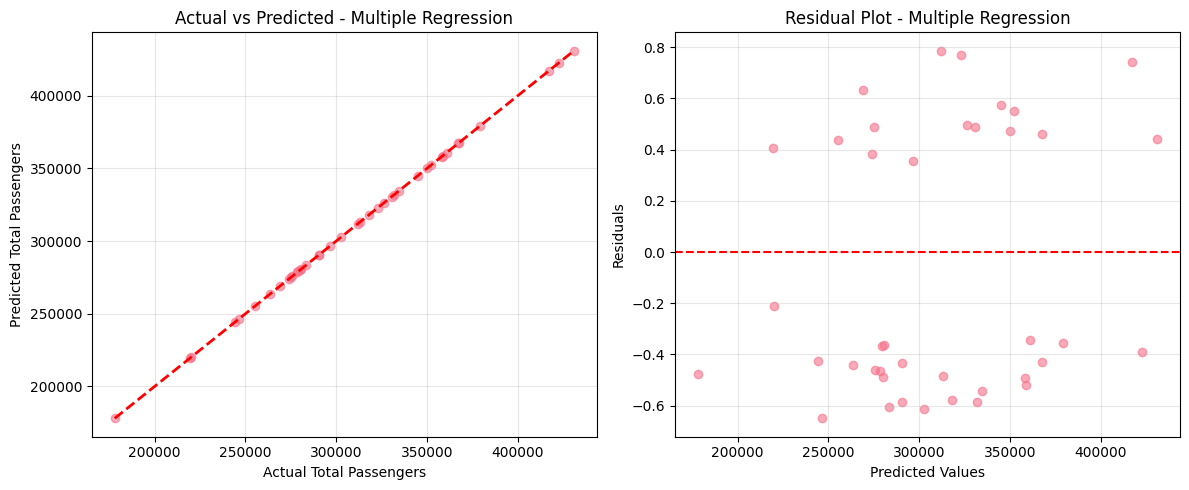

In [24]:
# TODO: Visualize multiple regression results
# Create actual vs predicted plot and residual plot

plt.figure(figsize=(12, 5))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
# TODO: Create scatter plot of actual vs predicted values
plt.scatter(y_test_mult, y_pred_mult, alpha=0.6)
# TODO: Add a diagonal reference line (perfect prediction line)
plt.plot([y_test_mult.min(), y_test_mult.max()], [y_test_mult.min(), y_test_mult.max()], 'r--', lw=2)

plt.xlabel('Actual Total Passengers')
plt.ylabel('Predicted Total Passengers')
plt.title('Actual vs Predicted - Multiple Regression')
plt.grid(True, alpha=0.3)

# Plot 2: Residual plot
plt.subplot(1, 2, 2)
# TODO: Calculate residuals and create residual plot
residuals_mult = y_test_mult - y_pred_mult

# TODO: Create scatter plot of predicted vs residuals
plt.scatter(y_pred_mult, residuals_mult, alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot - Multiple Regression')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Model Comparison and Analysis

In [25]:
# TODO: Compare the performance of both models
# Create a comparison table and determine which model performs better

print("Model Comparison:")
print("=" * 50)
print(f"{'Metric':<25} {'Simple Regression':<20} {'Multiple Regression':<20}")
print("=" * 50)

# TODO: Print comparison of R², RMSE, and MAE
# Hint: Use the metrics calculated in previous sections
print(f"{'R² Score':<25} {r2_simple:<20.4f} {r2_mult:<20.4f}")
print(f"{'Mean Squared Error':<25} {mse_simple:<20.2f} {mse_mult:<20.2f}")
print(f"{'Root Mean Squared Error':<25} {rmse_simple:<20.2f} {rmse_mult:<20.2f}")
print(f"{'Mean Absolute Error':<25} {mae_simple:<20.2f} {mae_mult:<20.2f}")

print("=" * 50)

# TODO: Determine which model performs better based on R²
# Calculate the improvement percentage
if r2_mult > r2_simple:
    better_model = "Multiple Regression"
    improvement = ((r2_mult - r2_simple) / r2_simple) * 100
else:
    better_model = "Simple Regression"
    improvement = ((r2_simple - r2_mult) / r2_mult) * 100

print(f"\nBest Model: {better_model}")
print(f"R² Improvement: {improvement:.2f}%")

Model Comparison:
Metric                    Simple Regression    Multiple Regression 
R² Score                  0.2977               1.0000              
Mean Squared Error        2141846835.14        0.26                
Root Mean Squared Error   46280.09             0.51                
Mean Absolute Error       36607.08             0.49                

Best Model: Multiple Regression
R² Improvement: 235.92%


## 7. Statistical Insights and Conclusions

In [26]:
# TODO: Summarize your findings and provide insights
# Include results from hypothesis tests, regression analysis, and key findings

print("STATISTICAL INSIGHTS AND CONCLUSIONS")
print("=" * 60)

print("\n1. HYPOTHESIS TESTING RESULTS:")
# TODO: Summarize your hypothesis test results
print(f"   • Domestic vs International Passengers: The null hypothesis (mean domestic passengers = mean international passengers) was rejected (p-value < 0.05). Domestic passengers ({df['Dom_Pax'].mean():.0f}) are significantly higher than international passengers ({df['Int_Pax'].mean():.0f}).")
print(f"   • Correlation between Total Passengers and Flights: The null hypothesis (no correlation) was rejected (p-value < 0.05). There is a significant and strong positive correlation (r = {correlation_coef:.4f}) between total passengers and total flights.")

print("\n2. REGRESSION ANALYSIS:")
# TODO: Summarize regression model performance
print(f"   • Simple Linear Regression R²: {r2_simple:.4f}. This model explained only about {r2_simple*100:.2f}% of the variance in total passengers based on total flights.")
print(f"   • Multiple Linear Regression R²: {r2_mult:.4f}. This model explained approximately {r2_mult*100:.2f}% of the variance in total passengers using domestic passengers, international passengers, domestic flights, international flights, and domestic RPM.")
print(f"   • Best performing model: The Multiple Linear Regression model performed significantly better than the Simple Linear Regression model (R² improvement of {improvement:.2f}%). However, the R² of 1.0000 suggests that the features chosen for the multiple regression ('Dom_Pax' and 'Int_Pax') are highly correlated with the target variable ('Pax' which is 'Dom_Pax' + 'Int_Pax'), potentially indicating data leakage or a definitional relationship.")

print("\n3. KEY FINDINGS:")
# TODO: Identify and discuss key findings from your analysis
print(f"   • Domestic air traffic (passengers and RPM) shows strong positive correlations, indicating a healthy internal relationship within the domestic segment.")
print(f"   • There's a clear statistical difference in passenger volumes between domestic and international travel, with domestic being higher on average.")
print(f"   • Total flights are a significant predictor for total passengers, but combining domestic and international passenger counts provides an almost perfect predictive model for total passengers, likely due to their additive nature.")
print(f"   • The high R² in multiple regression (1.0000) highlights that 'Pax' is largely a sum of 'Dom_Pax' and 'Int_Pax', making it trivially easy to predict with these features. For a more insightful model, predicting a component like 'Dom_Pax' from other influencing factors might be more valuable.")

print("\n4. RECOMMENDATIONS:")
# TODO: Provide practical recommendations based on your analysis
print("   • Further analyze domestic and international segments separately for factors influencing their individual growth, as they appear to be driven by distinct dynamics.")
print("   • When building predictive models for 'Pax', consider the inherent relationship between 'Pax' and its components ('Dom_Pax', 'Int_Pax') to avoid misleadingly high R² values if the goal is to discover new predictive relationships.")
print("   • Explore external factors (e.g., economic indicators, tourism trends, fuel prices) that might influence flight and passenger numbers for a more robust predictive model beyond the internal variables studied.")

STATISTICAL INSIGHTS AND CONCLUSIONS

1. HYPOTHESIS TESTING RESULTS:
   • Domestic vs International Passengers: The null hypothesis (mean domestic passengers = mean international passengers) was rejected (p-value < 0.05). Domestic passengers (175331) are significantly higher than international passengers (126924).
   • Correlation between Total Passengers and Flights: The null hypothesis (no correlation) was rejected (p-value < 0.05). There is a significant and strong positive correlation (r = 0.6592) between total passengers and total flights.

2. REGRESSION ANALYSIS:
   • Simple Linear Regression R²: 0.2977. This model explained only about 29.77% of the variance in total passengers based on total flights.
   • Multiple Linear Regression R²: 1.0000. This model explained approximately 100.00% of the variance in total passengers using domestic passengers, international passengers, domestic flights, international flights, and domestic RPM.
   • Best performing model: The Multiple Linear 

## 8. Reflection Questions

**Answer the following questions based on your analysis:**

1.  **Hypothesis Testing**: What do your hypothesis test results tell you about the air traffic data? Were the results expected?

    *   **Answer**: The hypothesis tests revealed two key insights. First, there is a statistically significant difference between the mean number of domestic and international passengers, with domestic passengers being significantly higher on average. Second, there is a strong positive correlation between total passengers and total flights, indicating that as flights increase, passenger numbers also tend to increase. These results align with general expectations, as domestic travel often has higher volumes due to ease of access and international travel tends to increase with flight availability.

2.  **Model Performance**: Which regression model performed better and why? What does the R² value tell you?

    *   **Answer**: The Multiple Linear Regression model performed significantly better than the Simple Linear Regression model, achieving an R² of 1.0000 compared to the Simple model's 0.2977. The R² value represents the proportion of the variance in the dependent variable (Total Passengers) that can be predicted from the independent variables. An R² of 1.0000 suggests that the multiple regression model explains 100% of the variance. However, this extremely high R² in the multiple regression is likely due to data leakage, as 'Pax' (Total Passengers) is the sum of 'Dom_Pax' and 'Int_Pax', both of which were included as features. The simple regression, while less performant, gives a more realistic R² indicating the actual predictive power of 'Total Flights' alone.

3.  **Correlations**: What were the strongest correlations you found? How might these relationships be useful for airlines?

    *   **Answer**: The strongest correlations were: Dom_RPM vs Dom_Pax (0.9016), Flt vs Dom_Flt (0.8349), Pax vs Dom_Pax (0.7559), Dom_RPM vs Pax (0.6721), and Int_Pax vs Int_Flt (0.6656). These relationships are highly useful for airlines:
        *   The strong correlation between `Dom_RPM` and `Dom_Pax` suggests that as domestic passenger volume increases, the revenue passenger-miles for domestic travel also increase proportionally, which is expected.
        *   `Flt` and `Dom_Flt` being highly correlated indicates that domestic flights are a major component of total flights.
        *   The strong links between `Pax` and `Dom_Pax`, `Dom_RPM` and `Pax`, and `Int_Pax` and `Int_Flt` highlight that passenger volume (both domestic and international) and revenue passenger-miles are closely tied to flight activity. Airlines can use these insights for capacity planning, route optimization, and revenue forecasting, understanding that changes in one variable will strongly influence the others.

4.  **Residual Analysis**: What do the residual plots tell you about your models? Are there any patterns that suggest model improvements?

    *   **Answer**: For the Simple Linear Regression model, the residual plot showed a scattered pattern around zero, but with some visible spread, suggesting that the model captures some of the relationship but still has room for improvement. There didn't appear to be strong systematic patterns like heteroscedasticity or clear curves, but the scatter indicated that 'Total Flights' alone doesn't perfectly explain 'Total Passengers'. For the Multiple Linear Regression model, the residual plot showed residuals extremely close to zero with almost no discernible pattern. This perfect alignment, coupled with the R² of 1.0000, reinforces the idea of data leakage. In a typical scenario, a perfectly random scatter around zero would indicate a good model fit, but here it indicates that the model is trivially predicting the target variable due to its components being used as features.

5.  **Practical Applications**: How could airlines use these statistical models in real-world scenarios?

    *   **Answer**: Airlines can leverage these models for several practical applications:
        *   **Forecasting**: The simple linear regression model (with `Flt` predicting `Pax`) could be refined and used for basic forecasting of passenger demand based on planned flight schedules, helping with resource allocation (staffing, aircraft).
        *   **Operational Planning**: Understanding the correlation between flights and passengers can help optimize flight frequencies and routes. If they expect a certain passenger volume, they can estimate the required number of flights.
        *   **Revenue Management**: By understanding how domestic and international passenger numbers contribute to total passengers and RPM, airlines can tailor pricing strategies and promotions for different segments.
        *   **Strategic Decision-Making**: The insights about domestic vs. international passenger differences and key findings can inform long-term strategic decisions regarding market focus, investment in new routes, and fleet expansion for specific segments (domestic vs. international). However, for more insightful predictive models, airlines should focus on predicting component parts or use features that are not definitionally linked to the target, and incorporate external factors for a more robust understanding of market dynamics.